In [2]:
import pandas as pd

df = pd.read_csv("telecom_churn_dataset_7000_25features.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CustomerSupportCalls,LatePayments,DataUsageGB,AvgSessionMinutes,SatisfactionScore,Churn
0,CUST00001,Male,0,Yes,Yes,66,Yes,No phone service,DSL,No,...,Yes,Bank transfer (automatic),79.33,3975.92,1,1,128.02,61.31,4,No
1,CUST00002,Female,0,Yes,Yes,40,Yes,Yes,No,No internet service,...,Yes,Bank transfer (automatic),99.39,6878.30,1,0,111.47,10.61,4,No
2,CUST00003,Male,1,No,No,45,Yes,Yes,Fiber optic,No,...,Yes,Electronic check,22.39,6229.12,3,0,100.61,95.49,1,No
3,CUST00004,Male,0,Yes,Yes,54,Yes,No,No,No internet service,...,No,Credit card (automatic),31.56,2960.17,2,1,457.99,117.39,1,No
4,CUST00005,Male,1,No,No,10,No,No phone service,DSL,Yes,...,Yes,Mailed check,104.57,7262.00,2,0,17.49,83.78,3,Yes


In [3]:
df.shape

(7000, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7000 non-null   object 
 1   gender                7000 non-null   object 
 2   SeniorCitizen         7000 non-null   int64  
 3   Partner               7000 non-null   object 
 4   Dependents            7000 non-null   object 
 5   tenure                7000 non-null   int64  
 6   PhoneService          7000 non-null   object 
 7   MultipleLines         7000 non-null   object 
 8   InternetService       7000 non-null   object 
 9   OnlineSecurity        7000 non-null   object 
 10  OnlineBackup          7000 non-null   object 
 11  DeviceProtection      7000 non-null   object 
 12  TechSupport           7000 non-null   object 
 13  StreamingTV           7000 non-null   object 
 14  StreamingMovies       7000 non-null   object 
 15  Contract             

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CustomerSupportCalls,LatePayments,DataUsageGB,AvgSessionMinutes,SatisfactionScore
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,0.173714,36.223143,70.065141,4452.682477,2.025571,1.008571,251.403531,92.508800,3.015571
std,0.378891,21.012945,29.144549,2565.878097,1.448374,1.018439,143.866655,50.236341,1.409523
min,0.000000,0.000000,20.000000,50.510000,0.000000,0.000000,1.090000,5.020000,1.000000
25%,0.000000,18.000000,44.772500,2224.812500,1.000000,0.000000,127.085000,49.760000,2.000000
50%,0.000000,36.500000,70.035000,4431.150000,2.000000,1.000000,251.190000,93.070000,3.000000
75%,0.000000,54.000000,95.725000,6615.217500,3.000000,2.000000,374.180000,135.440000,4.000000
max,1.000000,72.000000,119.990000,8999.300000,9.000000,6.000000,499.830000,180.000000,5.000000


In [6]:
df.isnull().sum()

customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges            0
CustomerSupportCalls    0
LatePayments            0
DataUsageGB             0
AvgSessionMinutes       0
SatisfactionScore       0
Churn                   0
dtype: int64

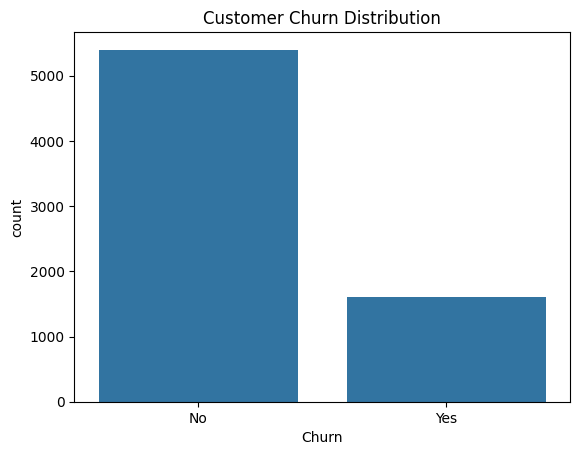

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

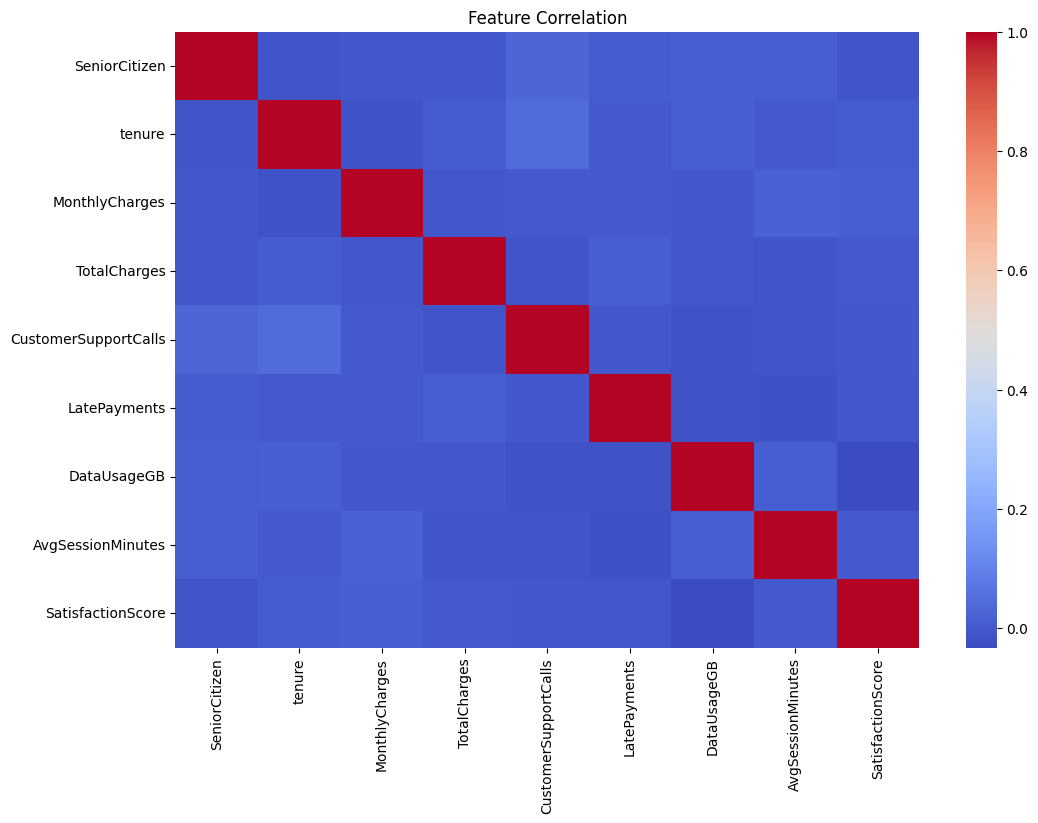

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [9]:
df = df.drop("customerID", axis=1)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [11]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CustomerSupportCalls,LatePayments,DataUsageGB,AvgSessionMinutes,SatisfactionScore,Churn
0,1,0,1,1,66,1,1,0,0,1,...,1,0,79.33,3975.92,1,1,128.02,61.31,4,0
1,0,0,1,1,40,1,2,2,1,2,...,1,0,99.39,6878.30,1,0,111.47,10.61,4,0
2,1,1,0,0,45,1,2,1,0,1,...,1,2,22.39,6229.12,3,0,100.61,95.49,1,0
3,1,0,1,1,54,1,0,2,1,0,...,0,1,31.56,2960.17,2,1,457.99,117.39,1,0
4,1,1,0,0,10,0,1,0,2,0,...,1,3,104.57,7262.00,2,0,17.49,83.78,3,1


In [12]:
# Define features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5600, 24)
(1400, 24)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.775


C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87      1084
           1       1.00      0.00      0.01       316

    accuracy                           0.78      1400
   macro avg       0.89      0.50      0.44      1400
weighted avg       0.83      0.78      0.68      1400



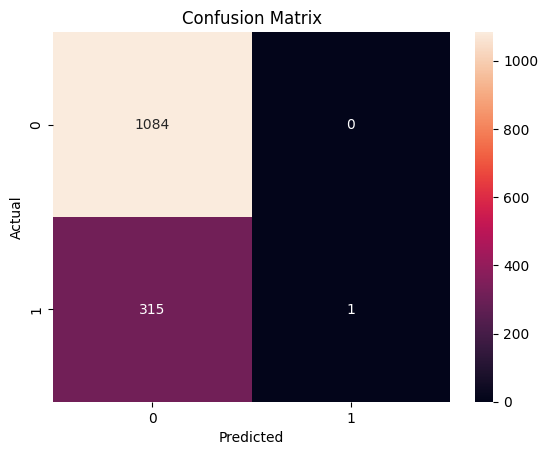

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.7714285714285715


In [18]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87      1084
           1       0.17      0.00      0.01       316

    accuracy                           0.77      1400
   macro avg       0.47      0.50      0.44      1400
weighted avg       0.64      0.77      0.68      1400



In [19]:
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

                 Feature  Importance
22     AvgSessionMinutes    0.104560
17        MonthlyCharges    0.102555
18          TotalCharges    0.101002
21           DataUsageGB    0.100588
4                 tenure    0.092818
14              Contract    0.047430
19  CustomerSupportCalls    0.046785
23     SatisfactionScore    0.038771
20          LatePayments    0.036768
16         PaymentMethod    0.035786


In [20]:
import joblib

joblib.dump(rf, "churn_prediction_model.pkl")

['churn_prediction_model.pkl']

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [24]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

Final Accuracy: 0.7735714285714286
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      1084
           1       0.00      0.00      0.00       316

    accuracy                           0.77      1400
   macro avg       0.39      0.50      0.44      1400
weighted avg       0.60      0.77      0.68      1400



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [27]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7742857142857142
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      1084
           1       0.00      0.00      0.00       316

    accuracy                           0.77      1400
   macro avg       0.39      0.50      0.44      1400
weighted avg       0.60      0.77      0.68      1400



C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
y.value_counts()

Churn
0    5399
1    1601
Name: count, dtype: int64

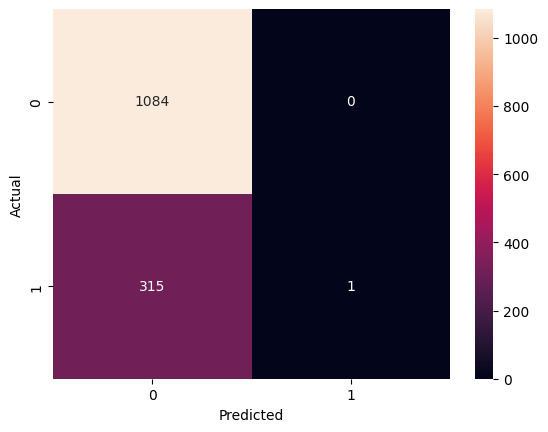

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
22     AvgSessionMinutes    0.100199
17        MonthlyCharges    0.100101
21           DataUsageGB    0.097152
18          TotalCharges    0.095769
4                 tenure    0.093320
14              Contract    0.067252
19  CustomerSupportCalls    0.044002
23     SatisfactionScore    0.040126
16         PaymentMethod    0.035921
20          LatePayments    0.034851


In [32]:
import joblib

joblib.dump(rf, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [33]:
import joblib

model = joblib.load("customer_churn_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [34]:
cd customer-churn-ml-project

[WinError 2] The system cannot find the file specified: 'customer-churn-ml-project'
C:\Users\rishi
